In [ ]:
#Importing pandas library
import pandas as pd
#Loading data into a DataFrame
prepared_data=pd.read_csv('/content/drive/MyDrive/SDGP Implementation/prepared_data.csv')

In [ ]:
prepared_data.shape

(5112, 6)

In [ ]:
prepared_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Income,5112.0,41913.573064,43262.760396,1301.187333,17261.639991,29872.735370,51272.858240,1.079728e+06
Rent,5112.0,9204.088674,9943.801312,260.237467,3630.873853,6292.240050,11145.873351,2.159457e+05
Transport,5112.0,2728.717380,2948.357784,81.228584,1100.187839,1903.612752,3320.296815,8.186150e+04
Eating_Out,5112.0,1469.207462,1523.910702,39.437523,565.846594,1025.793030,1793.581874,2.296261e+04
Healthcare,5112.0,1677.181533,1741.424410,53.500761,668.028388,1178.053294,2035.794094,3.600153e+04
Education,5112.0,2500.048033,3323.287012,0.000000,578.472099,1641.318384,3309.968110,8.166509e+04


In [ ]:
prepared_data.head()

,Income,Rent,Transport,Eating_Out,Healthcare,Education
0,101455.600247,15218.340037,7106.130005,5040.249158,4571.118217,0.000000
1,6492.016466,973.802470,494.824192,309.239688,222.648418,590.048039
2,38574.647021,7714.929404,2614.478029,1267.553419,1196.044202,3475.976780
3,11946.071980,2389.214396,641.888253,475.929401,404.436749,782.135316
4,11296.833460,2259.366692,763.560869,553.772450,503.306245,804.278678


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

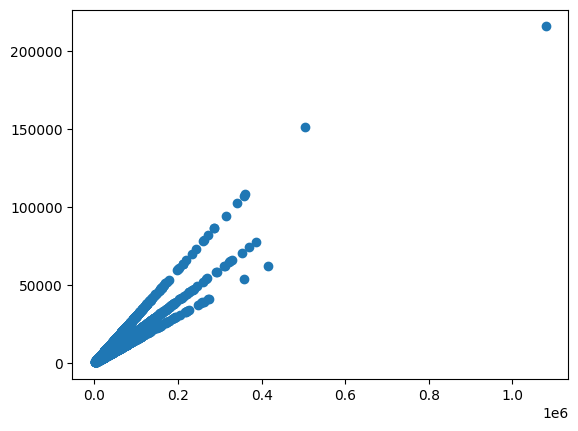

In [ ]:
plt.scatter(prepared_data['Income'],prepared_data['Rent'])

In [ ]:
def find_outliers_IQR(prepared_data):
  q1=prepared_data.quantile(0.25)
  q3=prepared_data.quantile(0.75)
  IQR=q3-q1
  outliers = prepared_data[((prepared_data<(q1-1.5*IQR))|(prepared_data>(q3+1.5*IQR)))]
  return outliers

In [ ]:
outliers = find_outliers_IQR(prepared_data['Rent'])
print("number of outliers: "+ str(len(outliers)))
outliers

number of outliers: 371


,Rent
12,31467.003913
24,34609.353222
45,38224.868917
79,30674.009739
83,33592.587592
...,...
5024,28480.425852
5033,30347.893971
5045,28986.973812
5075,29738.091778


In [ ]:
def remove_outliers_IQR(prepared_data, column):
    Q1 = prepared_data[column].quantile(0.25)
    Q3 = prepared_data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return prepared_data[(prepared_data[column] >= lower_bound) & (prepared_data[column] <= upper_bound)]

In [ ]:
outliers = find_outliers_IQR(prepared_data['Rent'])
print("Number of outliers before removal:", len(outliers))


Number of outliers before removal: 371


In [ ]:
cleaned_data = remove_outliers_IQR(prepared_data, 'Rent')


In [ ]:
print("Number of records after outlier removal:", len(cleaned_data))

Number of records after outlier removal: 4741


In [ ]:
# Save the cleaned dataset
cleaned_data.to_csv('', index=False)

# Download the new file
from google.colab import files
files.download('remove_out1.csv')

# Display the first few rows
cleaned_data.head()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Income,Rent,Transport,Eating_Out,Healthcare,Education
0,101455.600247,15218.340037,7106.130005,5040.249158,4571.118217,0.000000
1,6492.016466,973.802470,494.824192,309.239688,222.648418,590.048039
2,38574.647021,7714.929404,2614.478029,1267.553419,1196.044202,3475.976780
3,11946.071980,2389.214396,641.888253,475.929401,404.436749,782.135316
4,11296.833460,2259.366692,763.560869,553.772450,503.306245,804.278678


In [ ]:
#Importing pandas library
import pandas as pd
#Loading data into a DataFrame
cleaned_data=pd.read_csv('/content/drive/MyDrive/SDGP Implementation/remove_out1 (1).csv')

In [ ]:
cleaned_data.shape

(4741, 6)

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

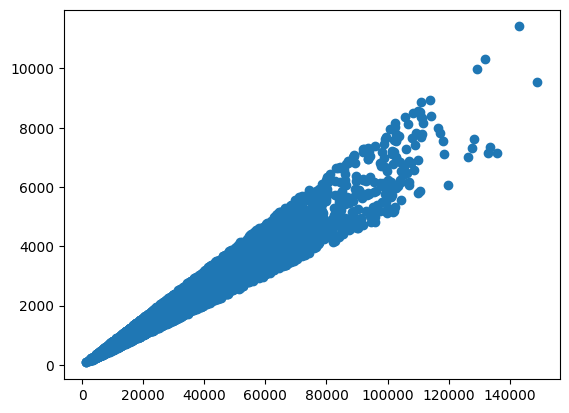

In [ ]:
plt.scatter(cleaned_data['Income'],cleaned_data['Transport'])

In [ ]:
def find_outliers_IQR(cleaned_data):
  q1=cleaned_data.quantile(0.25)
  q3=cleaned_data.quantile(0.75)
  IQR=q3-q1
  outliers = cleaned_data[((cleaned_data<(q1-1.5*IQR))|(cleaned_data>(q3+1.5*IQR)))]
  return outliers

In [ ]:
outliers = find_outliers_IQR(cleaned_data['Transport'])
print("number of outliers: "+ str(len(outliers)))
outliers

number of outliers: 155


,Transport
0,7106.130005
106,6380.447734
110,5735.878301
138,8927.669650
177,6183.684822
...,...
4573,7048.985526
4626,6661.376045
4646,6399.377466
4653,7995.630141


In [ ]:
def remove_outliers_IQR(cleaned_data, column):
    Q1 = cleaned_data[column].quantile(0.25)
    Q3 = cleaned_data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return cleaned_data[(cleaned_data[column] >= lower_bound) & (cleaned_data[column] <= upper_bound)]

In [ ]:
outliers = find_outliers_IQR(cleaned_data['Transport'])
print("Number of outliers before removal:", len(outliers))


Number of outliers before removal: 155


In [ ]:
cleaned_data2 = remove_outliers_IQR(cleaned_data, 'Transport')

In [ ]:
print("Number of records after outlier removal:", len(cleaned_data2))

Number of records after outlier removal: 4586


In [ ]:
# Save the cleaned dataset
cleaned_data2.to_csv('remove_out2.csv', index=False)

# Download the new file
from google.colab import files
files.download('remove_out2.csv')

# Display the first few rows
cleaned_data2.head()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Income,Rent,Transport,Eating_Out,Healthcare,Education
1,6492.016466,973.802470,494.824192,309.239688,222.648418,590.048039
2,38574.647021,7714.929404,2614.478029,1267.553419,1196.044202,3475.976780
3,11946.071980,2389.214396,641.888253,475.929401,404.436749,782.135316
4,11296.833460,2259.366692,763.560869,553.772450,503.306245,804.278678
5,10367.216239,1555.082436,763.019588,292.243613,468.318337,0.000000


In [ ]:
cleaned_data2.shape

(4586, 6)